In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)

In [2]:
# load dataset
df= pd.read_excel("Online Retail.xlsx")

#check first few rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [6]:
df=df[df['CustomerID'].notna()]

print("rows after removing missing CustomerID:", len(df))
print("Unique customers:",df["CustomerID"].nunique())

rows after removing missing CustomerID: 406829
Unique customers: 4372


In [7]:
df=df[df['Quantity']>0]
print("Rows after removing returns:",len(df))

Rows after removing returns: 397924


In [8]:
df=df[df['UnitPrice']>0]
print("rows after removing invalid prices:",len(df))

rows after removing invalid prices: 397884


In [9]:
df['TotalAmount']=df['Quantity']*df['UnitPrice']

df[['Quantity', 'UnitPrice','TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [10]:
print("Final rows:",len(df))
print("Final unique customers",df['CustomerID'].nunique())
print("Date range",df['InvoiceDate'].min(), "to",df['InvoiceDate'].max())

Final rows: 397884
Final unique customers 4338
Date range 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [11]:
# PHASE 2

In [12]:
#Aggregate data at customer level
customer_summary=df.groupby('CustomerID').agg(
    total_revenue=('TotalAmount','sum'),
    total_orders=('InvoiceNo','nunique'),
    first_purchase=('InvoiceDate','min'),
    last_purchase=('InvoiceDate','max')).reset_index()
customer_summary.head()

,CustomerID,total_revenue,total_orders,first_purchase,last_purchase
0,12346.0,77183.60,1,2011-01-18 10:01:00,2011-01-18 10:01:00
1,12347.0,4310.00,7,2010-12-07 14:57:00,2011-12-07 15:52:00
2,12348.0,1797.24,4,2010-12-16 19:09:00,2011-09-25 13:13:00
3,12349.0,1757.55,1,2011-11-21 09:51:00,2011-11-21 09:51:00
4,12350.0,334.40,1,2011-02-02 16:01:00,2011-02-02 16:01:00


In [13]:
#calculate customer lifespan in days
customer_summary['customer_lifespan_days']=(customer_summary['last_purchase']-customer_summary['first_purchase']).dt.days


#Average Order Value
customer_summary['avg_order_value']=(customer_summary['total_revenue']/customer_summary['total_orders'])
customer_summary.head()

,CustomerID,total_revenue,total_orders,first_purchase,last_purchase,customer_lifespan_days,avg_order_value
0,12346.0,77183.60,1,2011-01-18 10:01:00,2011-01-18 10:01:00,0,77183.600000
1,12347.0,4310.00,7,2010-12-07 14:57:00,2011-12-07 15:52:00,365,615.714286
2,12348.0,1797.24,4,2010-12-16 19:09:00,2011-09-25 13:13:00,282,449.310000
3,12349.0,1757.55,1,2011-11-21 09:51:00,2011-11-21 09:51:00,0,1757.550000
4,12350.0,334.40,1,2011-02-02 16:01:00,2011-02-02 16:01:00,0,334.400000


In [14]:
#total customers
total_customers=customer_summary['CustomerID'].nunique()

#purchase frequency
purchase_frequency=customer_summary['total_orders'].sum()/total_customers

purchase_frequency

np.float64(4.272014753342554)

In [15]:
#convert customer lifetime from days to years
customer_summary['customer_lifetime_years']=(customer_summary['customer_lifespan_days']/365)

#calculate CLV
customer_summary['CLV']=(customer_summary['avg_order_value']*purchase_frequency * customer_summary['customer_lifetime_years'])
customer_summary[['CustomerID','CLV']].head()

,CustomerID,CLV
0,12346.0,0.000000
1,12347.0,2630.340512
2,12348.0,1482.979243
3,12349.0,0.000000
4,12350.0,0.000000


In [16]:
#summary of clv
customer_summary['CLV'].describe()

count      4338.000000
mean        663.470685
std        3257.372802
min           0.000000
25%           0.000000
50%         258.343011
75%         863.108702
max      201126.396067
Name: CLV, dtype: float64

In [17]:
#top 10 customers by clv
customer_summary.sort_values(by='CLV',ascending=False).head(10)

,CustomerID,total_revenue,total_orders,first_purchase,last_purchase,customer_lifespan_days,avg_order_value,customer_lifetime_years,CLV
3008,16446.0,168472.50,2,2011-05-18 09:52:00,2011-12-09 09:15:00,204,84236.250000,0.558904,201126.396067
55,12415.0,124914.53,21,2011-01-06 11:12:00,2011-11-15 14:22:00,313,5948.310952,0.857534,21791.036114
4201,18102.0,259657.30,60,2010-12-07 16:42:00,2011-12-09 11:50:00,366,4327.621667,1.002740,18538.314740
3728,17450.0,194550.79,46,2010-12-07 09:23:00,2011-12-01 13:29:00,359,4229.365000,0.983562,17770.902943
2502,15749.0,44534.30,3,2011-01-11 12:55:00,2011-04-18 13:20:00,97,14844.766667,0.265753,16853.301464
1689,14646.0,280206.02,73,2010-12-20 10:09:00,2011-12-08 12:12:00,353,3838.438630,0.967123,15858.758519
1284,14088.0,50491.81,13,2011-01-21 13:07:00,2011-11-29 16:16:00,312,3883.985385,0.854795,14183.129243
330,12753.0,21429.39,6,2010-12-12 11:44:00,2011-11-17 10:52:00,339,3571.565000,0.928767,14170.922927
3771,17511.0,91062.38,31,2010-12-01 10:19:00,2011-12-07 10:12:00,370,2937.496129,1.013699,12720.931278
453,12931.0,42055.96,15,2010-12-17 09:45:00,2011-11-18 12:39:00,336,2803.730667,0.920548,11025.935527


In [18]:
# PHASE 3

In [19]:
#get most recent date in dataset
snapshot_date=customer_summary['last_purchase'].max()
snapshot_date

Timestamp('2011-12-09 12:50:00')

In [20]:
#calculate recency
customer_summary['Recency']=(snapshot_date-customer_summary['last_purchase']).dt.days
customer_summary[['CustomerID','Recency']].head()

,CustomerID,Recency
0,12346.0,325
1,12347.0,1
2,12348.0,74
3,12349.0,18
4,12350.0,309


In [21]:
customer_summary['Frequency']=customer_summary['total_orders']


In [22]:
customer_summary['Monetary']=customer_summary['total_revenue']

In [23]:
customer_summary[['CustomerID','Recency','Frequency','Monetary']].head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


In [24]:
#R score (lower recency=better,so reverse labels)
customer_summary['R_score']=pd.qcut(customer_summary['Recency'],4,labels=[4,3,2,1])

#F score
customer_summary['F_score']=pd.qcut(customer_summary['Frequency'].rank(method='first'),4,labels=[1,2,3,4])

#M score
customer_summary['M_score']=pd.qcut(customer_summary['Monetary'],4,labels=[1,2,3,4])

In [25]:
customer_summary['RFM_score']=(customer_summary['R_score'].astype(str)+customer_summary['F_score'].astype(str)+customer_summary['M_score'].astype(str))
customer_summary[['CustomerID','RFM_score']].head()

,CustomerID,RFM_score
0,12346.0,114
1,12347.0,444
2,12348.0,234
3,12349.0,314
4,12350.0,112


In [26]:
#create customer segments based on RFM score
def rfm_segment(row):
    if row['R_score']>=3 and row['F_score']>=3 and row['M_score']>=3:
        return 'Champions'
    elif row['R_score']>=3 and row['F_score']>=2:
        return 'Loyal Customers'
    elif row['R_score']>=3 and row['F_score']==1:
        return 'Potential Loyals'
    elif row['R_score']==2 and row['F_score']>=2:
        return 'Needs Atention'
    elif row['R_score']==1 and row['F_score']>=2:
        return 'At risk'
    else:
        return 'Lost Customers'
customer_summary['RFM_segment']=customer_summary.apply(rfm_segment,axis=1)
customer_summary[['CustomerID','RFM_segment']].head()    

,CustomerID,RFM_segment
0,12346.0,Lost Customers
1,12347.0,Champions
2,12348.0,Needs Atention
3,12349.0,Potential Loyals
4,12350.0,Lost Customers


In [27]:
customer_summary['RFM_segment'].value_counts()

RFM_segment
Champions           1319
Lost Customers       826
Needs Atention       759
Loyal Customers      610
At risk              565
Potential Loyals     259
Name: count, dtype: int64

In [28]:
#backup files
customer_summary.to_csv("customer_rfm_clv.csv",index=False)
df.to_csv('cleaned_transactions.csv',index=False)

In [29]:
# PHASE 4 ADVANCED EDA

In [30]:
#Monthly revenue trend
monthly_revenue=(df.set_index('InvoiceDate').resample('ME')['TotalAmount'].sum().reset_index())

#Remove last incomplete month
monthly_revenue=monthly_revenue[monthly_revenue['InvoiceDate']<'2011-12-01']

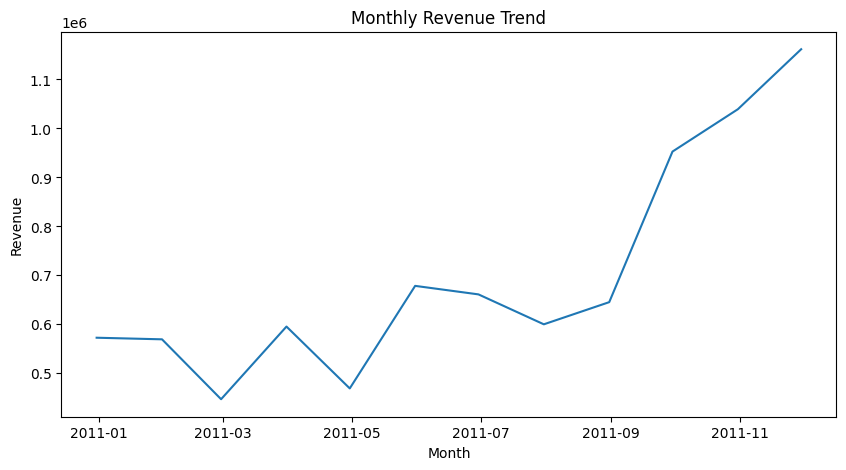

In [31]:
#Plotting
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_revenue,x='InvoiceDate',y='TotalAmount')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [32]:
#top 10 countries by revenue
country_revenue=(df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10).reset_index())
country_revenue

,Country,TotalAmount
0,United Kingdom,7308391.554
1,Netherlands,285446.340
2,EIRE,265545.900
3,Germany,228867.140
4,France,209024.050
5,Australia,138521.310
6,Spain,61577.110
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38378.330


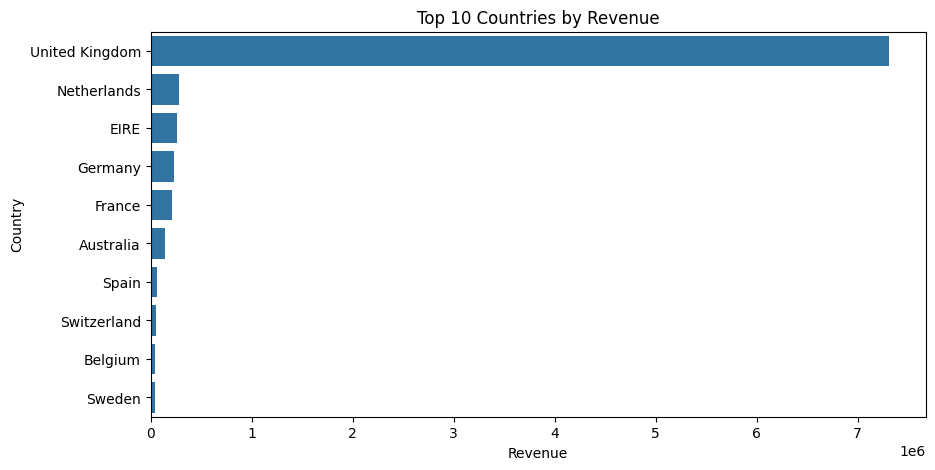

In [33]:
plt.figure(figsize=(10,5))
sns.barplot(data=country_revenue,x='TotalAmount',y='Country')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

In [34]:
#top 10 cust
top_customers=(df.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head(10).reset_index())
top_customers

,CustomerID,TotalAmount
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194550.79
3,16446.0,168472.50
4,14911.0,143825.06
5,12415.0,124914.53
6,14156.0,117379.63
7,17511.0,91062.38
8,16029.0,81024.84
9,12346.0,77183.60


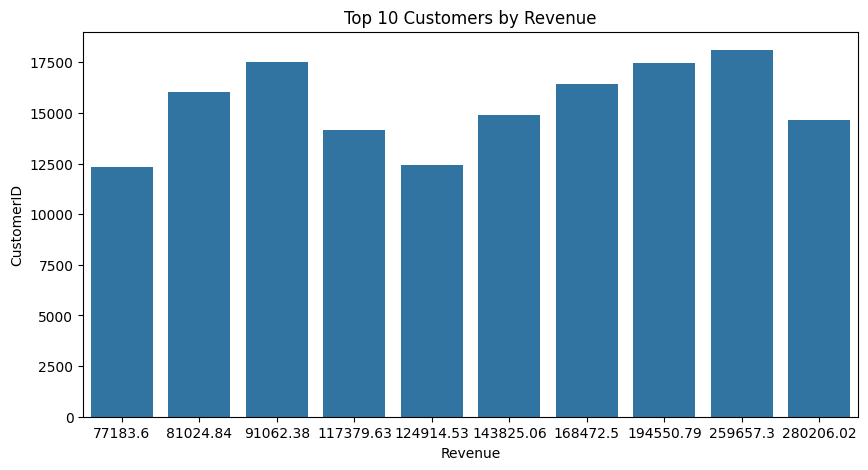

In [35]:
plt.figure(figsize=(10,5))
sns.barplot(data=top_customers,x='TotalAmount',y='CustomerID')
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("CustomerID")
plt.show()

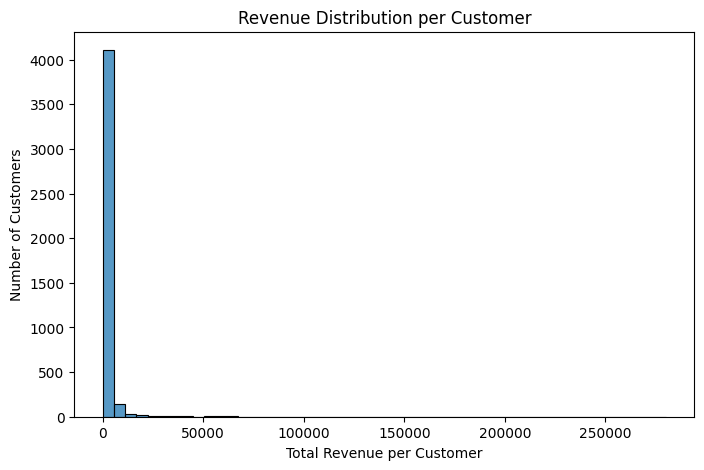

In [36]:
#Revenue Distribution (histogram)
plt.figure(figsize=(8,5))
sns.histplot(customer_summary['total_revenue'],bins=50)
plt.title("Revenue Distribution per Customer")
plt.xlabel("Total Revenue per Customer")
plt.ylabel("Number of Customers")
plt.show()

In [37]:
#Pareto Analysis
#Sort cust by revenue
pareto=(customer_summary.sort_values('total_revenue',ascending=False).reset_index(drop=True))


In [38]:
#Calculate Cumulative revenue %
pareto['CumulativeRevenue']=pareto['total_revenue'].cumsum()
total_revenue=pareto['total_revenue'].sum()

pareto['CumulativePercent']=(pareto['CumulativeRevenue']/total_revenue*100)
pareto.head()

,CustomerID,total_revenue,total_orders,first_purchase,last_purchase,customer_lifespan_days,avg_order_value,customer_lifetime_years,CLV,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_segment,CumulativeRevenue,CumulativePercent
0,14646.0,280206.02,73,2010-12-20 10:09:00,2011-12-08 12:12:00,353,3838.438630,0.967123,15858.758519,1,73,280206.02,4,4,4,444,Champions,280206.02,3.144352
1,18102.0,259657.30,60,2010-12-07 16:42:00,2011-12-09 11:50:00,366,4327.621667,1.002740,18538.314740,0,60,259657.30,4,4,4,444,Champions,539863.32,6.058115
2,17450.0,194550.79,46,2010-12-07 09:23:00,2011-12-01 13:29:00,359,4229.365000,0.983562,17770.902943,7,46,194550.79,4,4,4,444,Champions,734414.11,8.241280
3,16446.0,168472.50,2,2011-05-18 09:52:00,2011-12-09 09:15:00,204,84236.250000,0.558904,201126.396067,0,2,168472.50,4,2,4,424,Loyal Customers,902886.61,10.131807
4,14911.0,143825.06,201,2010-12-01 14:05:00,2011-12-08 15:54:00,372,715.547562,1.019178,3115.453874,0,201,143825.06,4,4,4,444,Champions,1046711.67,11.745750


In [39]:
#Find % of customers that generate 80% revenue
customer_80=pareto[pareto['CumulativePercent']<=80]

percentage_customers=len(customer_80)/len(pareto)*100
percentage_customers

26.09497464269249

In [40]:
#Revenue by RFM Segment
segment_revenue=(customer_summary.groupby('RFM_segment')['total_revenue'].sum().sort_values(ascending=False).reset_index())
segment_revenue

,RFM_segment,total_revenue
0,Champions,6506541.991
1,Needs Atention,955224.801
2,Loyal Customers,504670.830
3,At risk,456537.381
4,Lost Customers,396317.351
5,Potential Loyals,92115.550


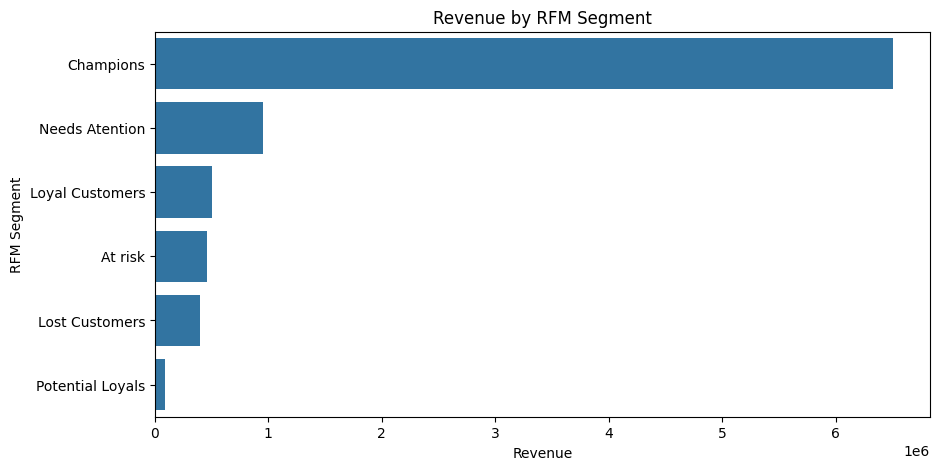

In [41]:
plt.figure(figsize=(10,5))
sns.barplot(data=segment_revenue,x='total_revenue',y='RFM_segment')
plt.title("Revenue by RFM Segment")
plt.xlabel("Revenue")
plt.ylabel("RFM Segment")
plt.show()

Key Findings:

Revenue is highly concentrated, with ~26% of customers generating 80% of total revenue.

Customer revenue distribution is strongly right-skewed, indicating a small group of high-value customers.
The “Champions” RFM segment contributes the majority of revenue.

Revenue is heavily concentrated in the United Kingdom, creating geographic dependency risk.
There is clear seasonality, with revenue peaking toward the end of the year.

Strategic Recommendations:

Prioritize retention of Champions through loyalty programs, exclusive offers, and premium support.
Upsell Loyal Customers with bundles and subscription-style offers to move them into the Champions segment.

Re-engage “Needs Attention” and “At Risk” customers using targeted campaigns and limited-time incentives.
Avoid overspending on Lost Customers, focusing instead on high-return segments.

Diversify geographically by exploring growth opportunities outside the UK market.

Business Impact:

Retaining high-value customers can significantly reduce revenue volatility.

Targeted segmentation-driven marketing can improve ROI compared to broad campaigns.

Focusing on top segments aligns marketing spend with revenue contribution.

In [42]:
df.to_csv("ecommerce_final_cleaned.csv",index=False)